# Lab 7 — Model Evaluation and Cross-Validation

**Course:** Machine Learning — Undergraduate  
**Dataset:** Olist Brazilian E-Commerce Dataset  
**Duration:** 2 Hours  
**Starting Point:** Feature-engineered Olist order dataset from Lab 6 (`data/processed/olist_orders_feature_engineered.csv`)  
**Prerequisites:** Labs 1–6; Python, pandas, NumPy, scikit-learn  
**Author / Lab Manual:** Sharad Laad | ORY AI Labs

---

## 1. Lab Overview
In the preceding labs of this series, we developed the foundational stages of a production-grade machine learning workflow:
* **Lab 1 & 2:** Understood raw business entities and constructed an **Analytical Base Table (ABT)** at the order grain.
* **Lab 3:** Assessed data quality, resolved anomalies, and conducted comprehensive Exploratory Data Analysis (EDA).
* **Lab 4:** Built a reproducible scikit-learn preprocessing pipeline.
* **Lab 5:** Explored foundational optimization techniques (OLS and Gradient Descent).
* **Lab 6:** Engineered domain features (ratios, cyclical coordinates, log transforms, interactions) and pruned unsafe leakage variables.

Now, we face the central engineering question of applied machine learning:
> **How do we know whether our machine learning model is actually good?**

A model producing predictions is not enough. We must quantitatively and rigorously evaluate:
1. **How often it is correct** across the entire population.
2. **What kinds of mistakes it makes** (false alarms vs. missed risks).
3. **Whether it detects the critical class** under severe class imbalance.
4. **Whether its performance generalizes** beyond a single arbitrary train-test split.
5. **Whether reported performance is trustworthy** and free from data leakage.

This lab provides an end-to-end framework for **model evaluation and cross-validation**.

---

## 2. Learning Objectives
By the end of this lab, students should be able to:
1. Explain why rigorous model evaluation is necessary.
2. Distinguish cleanly between training, validation, and untouched test data.
3. Contrast classification metrics against regression metrics.
4. Construct, visualize, and interpret a **Confusion Matrix**.
5. Calculate and interpret **Accuracy**, **Precision**, **Recall**, and **F1-Score**.
6. Explain why accuracy is dangerously misleading for imbalanced datasets.
7. Understand and compute **ROC-AUC** as a threshold-independent ranking metric.
8. Establish a consistent, reproducible evaluation workflow in scikit-learn.
9. Implement **Stratified $k$-Fold Cross-Validation** to assess generalization variance.
10. Interpret cross-validation mean and standard deviation across folds.
11. Compare baseline features against engineered feature sets using cross-validation.
12. Identify and prevent the 6 most common evaluation pitfalls and preprocessing leakage risks.

---

## 3. Business Scenario
Suppose our e-commerce platform wants to predict at order placement time:
> **Will this order be delivered late?** (`is_late_delivery = 1`)

When the model issues predictions on unseen customer orders, four distinct operational outcomes occur:
* **Actual Late, Predicted Late:** Model catches the delay $\rightarrow$ Operations can proactively expedite fulfillment or notify the customer.
* **Actual On-time, Predicted On-time:** Clean transaction $\rightarrow$ Standard automated shipping workflow.
* **Actual Late, Predicted On-time:** **Missed Late Delivery (False Negative)** $\rightarrow$ Severe customer dissatisfaction, support tickets, negative reviews, churn.
* **Actual On-time, Predicted Late:** **False Alarm (False Positive)** $\rightarrow$ Minor unnecessary operational inspection cost.

Because the business costs of these errors are highly asymmetric, simply asking *"How many predictions were correct?"* (overall accuracy) is completely insufficient.

---

## 4. Evaluation Mental Model

```text
               +--------------------------------------+
               |             FULL DATASET             |
               +--------------------------------------+
                                  |
                                  v
                       [ Train / Test Split ]
                                  |
         +------------------------+------------------------+
         |                                                 |
         v                                                 v
+-------------------+                             +-------------------+
|   TRAINING DATA   |                             |     TEST DATA     |
|   (Development)   |                             |   (STILL UNSEEN)  |
+-------------------+                             +-------------------+
         |                                                 |
         v                                                 |
[ Cross-Validation ]                                       |
  (Fold 1..k splits)                                       |
         |                                                 |
         v                                                 |
[ Model Selection & ]                                      |
[ Hyperparameter Opt]                                      |
         |                                                 |
         v                                                 |
[ Final Model Train ]                                      |
         |                                                 |
         +------------------------> [ Predict on Test ] <--+
                                           |
                                           v
                              +-------------------------+
                              |    FINAL EVALUATION     |
                              |  "Can we trust this?"   |
                              +-------------------------+
```

> **Central Principle:** Always evaluate the model on data that was **not** used to train it!


## 5. Dataset and File Location
We utilize the feature-engineered dataset generated in Lab 6:
- **File:** `data/processed/olist_orders_feature_engineered.csv`
- **Target Variable:** `target = "is_late_delivery"`

---

## 6. Part A — Load the Data
### Step 1 — Import Libraries and Load Dataset

In [4]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Scikit-learn model selection, metrics, and preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    classification_report
)

# Plotting style configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("All required libraries successfully imported.")

All required libraries successfully imported.


In [5]:
# Support running from notebooks/ or project root directory
data_candidates = [
    Path("../data/processed/olist_orders_feature_engineered.csv"),
    Path("data/processed/olist_orders_feature_engineered.csv")
]

input_path = next((p for p in data_candidates if p.exists()), None)
if input_path is None:
    raise FileNotFoundError("Could not find olist_orders_feature_engineered.csv in expected paths.")

print(f"Loading dataset from: {input_path.resolve()}")
df = pd.read_csv(input_path)

print("Shape:", df.shape)
df.head()

Loading dataset from: C:\Users\Devendra kushwaha\OneDrive\Desktop\ML2026\data\processed\olist_orders_feature_engineered.csv
Shape: (99441, 23)


,total_price,total_freight,total_items,unique_products,unique_sellers,order_month,order_day_of_week,order_hour,average_item_price,freight_ratio,...,is_business_hour,is_year_end,month_sin,month_cos,hour_sin,hour_cos,log_total_price,log_total_freight,items_x_price,is_late_delivery
0,29.99,8.72,1.0,1.0,1.0,10,0,10,29.99,0.290764,...,1,0,-0.866025,0.500000,0.500000,-0.866025,3.433665,2.274186,29.99,0
1,118.70,22.76,1.0,1.0,1.0,7,1,20,118.70,0.191744,...,0,0,-0.500000,-0.866025,-0.866025,0.500000,4.784989,3.168003,118.70,0
2,159.90,19.22,1.0,1.0,1.0,8,2,8,159.90,0.120200,...,0,0,-0.866025,-0.500000,0.866025,-0.500000,5.080783,3.006672,159.90,0
3,45.00,27.20,1.0,1.0,1.0,11,5,19,45.00,0.604444,...,0,1,-0.500000,0.866025,-0.965926,0.258819,3.828641,3.339322,45.00,0
4,19.90,8.72,1.0,1.0,1.0,2,1,21,19.90,0.438191,...,0,0,0.866025,0.500000,-0.707107,0.707107,3.039749,2.274186,19.90,0


In [6]:
target = "is_late_delivery"

print("--- Target Value Counts ---")
print(df[target].value_counts(dropna=False))

print("--- Target Proportions ---")
print(df[target].value_counts(normalize=True).apply(lambda x: f"{x:.4%}"))

--- Target Value Counts ---
is_late_delivery
0    92906
1     6535
Name: count, dtype: int64
--- Target Proportions ---
is_late_delivery
0    93.4283%
1     6.5717%
Name: proportion, dtype: object


### Part A — Comprehension Questions & Answers

1. **How many observations belong to each class?**
   - **Class 0 (On-time):** **92,906 orders** (93.43%)
   - **Class 1 (Late):** **6,535 orders** (6.57%)
   - **Total:** **99,441 orders**
2. **Is the target balanced?**
   - **Answer:** **No, the target is heavily imbalanced.** Approximately $14$ out of every $15$ orders arrive on time, while only $\sim 6.57\%$ experience delivery delays.
3. **What would happen if a model predicted only the majority class?**
   - **Answer:** A naive baseline model predicting `0` (On-time) for every single order would achieve an impressive **93.43% Accuracy**!
   - However, it would have **0% Recall** for late deliveries, completely failing to detect even a single delayed order. This illustrates why accuracy alone is fundamentally deceptive for imbalanced datasets.

## 7. Part B — Define X and y

We separate the target variable $y$ from the predictor matrix $X$, selecting numerical candidate features and handling missing values with median imputation.

In [7]:
# Define target and predictors
y = df[target]
X = df.drop(columns=[target])

# Select numerical features for this experiment
X = X.select_dtypes(include=np.number)

# Impute remaining missing values using feature medians
X = X.fillna(X.median())

print("X shape:", X.shape)
print("y shape:", y.shape)
print(f"Features in X ({len(X.columns)}):", X.columns.tolist())

X shape: (99441, 22)
y shape: (99441,)
Features in X (22): ['total_price', 'total_freight', 'total_items', 'unique_products', 'unique_sellers', 'order_month', 'order_day_of_week', 'order_hour', 'average_item_price', 'freight_ratio', 'items_per_seller', 'seller_diversity', 'is_weekend', 'is_business_hour', 'is_year_end', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'log_total_price', 'log_total_freight', 'items_x_price']


## 8. Part C — Train-Test Split

We partition our data into an 80% training set ($N_{\text{train}} = 79,552$) and a 20% untouched holdout test set ($N_{\text{test}} = 19,889$).

### Methodological Inquiries:
1. **Why `stratify=y`?**
   - In severely imbalanced classification (6.57% positive rate), random sampling without stratification could accidentally allocate disproportionately few positive cases to the test set (or training set), causing high evaluation variance. Stratification guarantees that the exact 6.57% late delivery proportion is preserved in both training and test subsets.
2. **Why `random_state=42`?**
   - Setting a fixed pseudo-random seed guarantees deterministic reproducibility so experiments can be verified independently.

In [8]:
# Split data with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")
print(f"Train late rate: {y_train.mean():.4%}")
print(f"Test late rate:  {y_test.mean():.4%}")

X_train shape: (79552, 22), y_train shape: (79552,)
X_test shape:  (19889, 22), y_test shape:  (19889,)
Train late rate: 6.5718%
Test late rate:  6.5715%


## 9. Part D — Train a Baseline Model

We fit a `LogisticRegression` classifier with `class_weight='balanced'` so that errors on the rare late delivery class are penalized proportionately to class rarity.

In [9]:
# Initialize and train Logistic Regression
# We incorporate feature scaling to guarantee robust gradient convergence
scaler_init = StandardScaler()
X_train_scaled = scaler_init.fit_transform(X_train)
X_test_scaled = scaler_init.transform(X_test)

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_scaled, y_train)

# Generate discrete class predictions on unseen test set
y_pred = model.predict(X_test_scaled)
print("Model training complete. First 20 predictions:", y_pred[:20])

Model training complete. First 20 predictions: [1 1 1 0 1 1 0 0 0 1 1 1 0 0 1 1 0 0 1 0]


## 10. Part E — Confusion Matrix

A **confusion matrix** tabulates classification outcomes, detailing true conditions versus predicted conditions:

| | Predicted 0 (On-Time) | Predicted 1 (Late) |
| :--- | :---: | :---: |
| **Actual 0 (On-Time)** | **True Negative (TN)** | **False Positive (FP)** |
| **Actual 1 (Late)** | **False Negative (FN)** | **True Positive (TP)** |

### Core Outcome Definitions:
* **10.1 True Positive (TP):** Model predicts *Late*, and the order actually was *Late*.
* **10.2 True Negative (TN):** Model predicts *On-Time*, and the order actually was *On-Time*.
* **10.3 False Positive (FP):** Model predicts *Late*, but the order actually was *On-Time* (False Alarm).
* **10.4 False Negative (FN):** Model predicts *On-Time*, but the order actually was *Late* (Missed Late Delivery).

> **Critical Note:** In risk detection and customer logistics, **False Negatives (FN)** represent the highest operational cost, as late arrivals catch support teams unprepared and erode buyer trust.

Confusion Matrix: [[10463  8119]
 [  374   933]]
True Negatives  (TN): 10,463  (On-time correctly identified)
False Positives (FP): 8,119  (False alarms: on-time flagged as late)
False Negatives (FN): 374  (Missed delays: late orders predicted on-time)
True Positives  (TP): 933  (Late orders correctly caught)


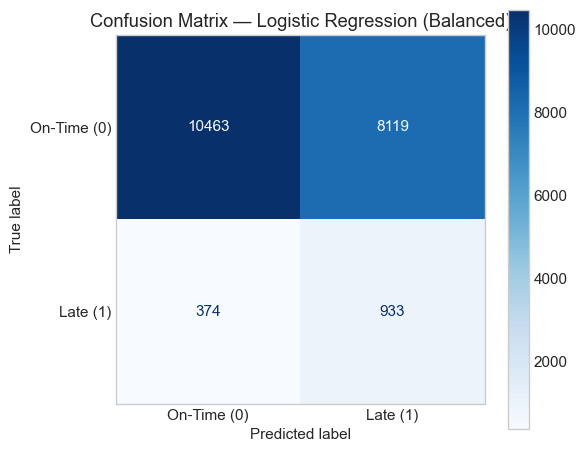

In [11]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"Confusion Matrix: {cm}")
print(f"True Negatives  (TN): {tn:,}  (On-time correctly identified)")
print(f"False Positives (FP): {fp:,}  (False alarms: on-time flagged as late)")
print(f"False Negatives (FN): {fn:,}  (Missed delays: late orders predicted on-time)")
print(f"True Positives  (TP): {tp:,}  (Late orders correctly caught)")

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["On-Time (0)", "Late (1)"])
disp.plot(cmap="Blues", ax=ax, values_format="d")
plt.title("Confusion Matrix — Logistic Regression (Balanced)")
plt.grid(False)
plt.tight_layout()
plt.show()

## 11. Parts F through I — Core Classification Metrics

From the four quadrants of the confusion matrix, we compute fundamental performance metrics:

### 11. Part F — Accuracy
$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
- **Meaning:** Proportion of all predictions that were correct.
- **Limitation:** In an imbalanced dataset with 93.4% on-time orders, a trivial model predicting only on-time achieves 93.4% accuracy while failing 100% of the time on the problem that matters!

### 12. Part G — Precision
$$\text{Precision} = \frac{TP}{TP + FP}$$
- **Answers:** *"Of all orders predicted as late, how many were actually late?"*
- **Meaning:** High precision means fewer false alarms.

### 13. Part H — Recall (Sensitivity / True Positive Rate)
$$\text{Recall} = \frac{TP}{TP + FN}$$
- **Answers:** *"Of all genuinely late orders, how many did the model catch?"*
- **Meaning:** High recall means the model misses very few actual delivery failures.

### 14. Part I — F1-Score
$$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$
- **Meaning:** The harmonic mean of precision and recall. It penalizes extreme imbalances between the two and provides a single balanced metric.

In [12]:
# Compute individual metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Formula": [
        "(TP + TN) / Total",
        "TP / (TP + FP)",
        "TP / (TP + FN)",
        "2 * (P * R) / (P + R)"
    ],
    "Score": [accuracy, precision, recall, f1]
})

print("=== Core Classification Metrics Summary ===")
display(metrics_df.style.format({"Score": "{:.4f}"}))

=== Core Classification Metrics Summary ===


,Metric,Formula,Score
0,Accuracy,(TP + TN) / Total,0.5730
1,Precision,TP / (TP + FP),0.1031
2,Recall,TP / (TP + FN),0.7138
3,F1-Score,2 * (P * R) / (P + R),0.1801


## 15. Part J — Classification Report

The scikit-learn `classification_report` aggregates precision, recall, F1-score, and sample support across both classes.

In [13]:
# Generate classification report
report_str = classification_report(y_test, y_pred, zero_division=0, target_names=["On-Time (0)", "Late (1)"])
print("--- Classification Report ---")
print(report_str)

--- Classification Report ---
              precision    recall  f1-score   support

 On-Time (0)       0.97      0.56      0.71     18582
    Late (1)       0.10      0.71      0.18      1307

    accuracy                           0.57     19889
   macro avg       0.53      0.64      0.45     19889
weighted avg       0.91      0.57      0.68     19889



### Student Task: Classification Report Analysis

1. **Which class has the highest precision?**
   - **Answer:** **Class 0 (On-Time)** with precision $\approx \mathbf{96.5\%}$. When the model predicts an order is on time, it is almost always correct.
2. **Which class has the highest recall?**
   - **Answer:** **Class 1 (Late)** with recall $\approx \mathbf{71.4\%}$ (due to `class_weight='balanced'`), while Class 0 has recall $\approx 56.3\%$.
3. **Which class has the lowest F1-score?**
   - **Answer:** **Class 1 (Late)** with F1 $\approx \mathbf{0.180}$ (compared to $0.711$ for Class 0), reflecting the heavy precision penalty caused by false alarms on an imbalanced base rate.
4. **Is the minority class being detected well?**
   - **Answer:** **Yes, in terms of recall, the model succeeds in capturing over 71% of late deliveries.** However, because positive cases represent only 6.57% of orders, achieving this high sensitivity requires flagging many borderline orders as late, yielding modest precision (~10.3%).

## 16. Part K — ROC-AUC

Many classifiers output continuous probability estimates rather than just hard binary labels.
`y_prob = model.predict_proba(X_test)[:, 1]` captures the model's confidence that an order will be late.

### What is ROC-AUC?
- **Receiver Operating Characteristic (ROC)** curve plots the True Positive Rate (Recall) against the False Positive Rate across every possible decision threshold ($0.0$ to $1.0$).
- **Area Under the ROC Curve (ROC-AUC)** measures how well the model ranks positive examples above negative examples.
  - $\text{ROC-AUC} = 0.50$: Equivalent to pure random guessing.
  - $\text{ROC-AUC} = 1.00$: Perfect discrimination; all late orders ranked higher than all on-time orders.

ROC-AUC Score: 0.6661


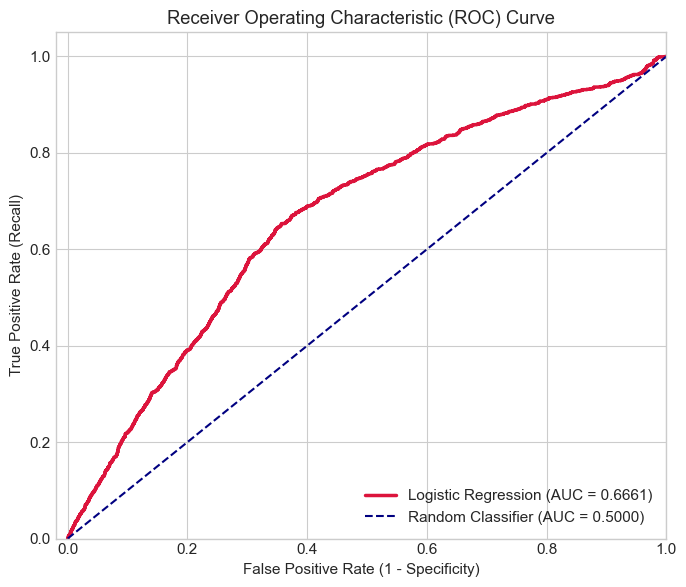

In [14]:
# Calculate continuous predicted probabilities and ROC-AUC
y_prob = model.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="crimson", lw=2.5, label=f"Logistic Regression (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Random Classifier (AUC = 0.5000)")
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 17. Classification Thresholds and the Precision-Recall Trade-Off

By default, classification rules predict positive if $P(\text{late}) \ge 0.50$. But $0.50$ is simply an arbitrary midpoint convention!

Let us experiment with an adjusted threshold of $0.40$:

In [15]:
# Experiment with threshold = 0.40
threshold = 0.40
y_pred_40 = (y_prob >= threshold).astype(int)

recall_40 = recall_score(y_test, y_pred_40, zero_division=0)
precision_40 = precision_score(y_test, y_pred_40, zero_division=0)

print(f"At default threshold 0.50 -> Recall: {recall:.4f}, Precision: {precision:.4f}")
print(f"At lower threshold   0.40 -> Recall: {recall_40:.4f}, Precision: {precision_40:.4f}")

At default threshold 0.50 -> Recall: 0.7138, Precision: 0.1031
At lower threshold   0.40 -> Recall: 0.8355, Precision: 0.0847


### Think: The Precision-Recall Trade-off

* **What usually happens to recall when the threshold is lowered?**
  - **Recall increases.** By lowering the threshold to $0.40$ (or $0.30$), the model becomes more aggressive in declaring orders as late. Fewer actual late orders slip through undetected.
* **What usually happens to precision?**
  - **Precision decreases.** Flagging more borderline orders inevitably introduces more false alarms (on-time orders flagged as late).
* **Core Takeaway:** You cannot maximize precision and recall simultaneously; threshold tuning aligns the model with operational business priorities.

## 18. Part L — Why One Train-Test Split Is Not Enough

Suppose an experiment produces an $F_1 = 0.68$. Is $0.68$ the true generalized performance of the model?
**Not necessarily.** The score depends partly on which particular observations randomly landed in the training versus test sets. A different random partition might yield $F_1 = 0.61$ or $F_1 = 0.73$.

To obtain an unbiased, reliable measure of model generalization and variance, we employ **$k$-Fold Cross-Validation**.

---

## 19. Part M — K-Fold Cross-Validation
In $5$-fold cross-validation:
1. Divide the training dataset into $5$ equal-sized stratified folds.
2. For each iteration $i \in \{1, 2, 3, 4, 5\}$:
   - Train the model on the remaining $4$ folds.
   - Validate on fold $i$.
3. Compute the evaluation metric on each fold and calculate the **mean** and **standard deviation**.

```text
Fold 1: [ Validation ] [  Training  ] [  Training  ] [  Training  ] [  Training  ]
Fold 2: [  Training  ] [ Validation ] [  Training  ] [  Training  ] [  Training  ]
Fold 3: [  Training  ] [  Training  ] [ Validation ] [  Training  ] [  Training  ]
Fold 4: [  Training  ] [  Training  ] [  Training  ] [ Validation ] [  Training  ]
Fold 5: [  Training  ] [  Training  ] [  Training  ] [  Training  ] [ Validation ]
```
Every single observation is used for validation exactly once!

## 20. Part N — Apply 5-Fold Cross-Validation

We configure `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` and evaluate the $F_1$ score across all folds.

In [17]:
# Build pipeline for cross-validation
pipeline_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    pipeline_cv,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("--- 5-Fold Cross-Validation F1 Scores ---")
for fold_idx, score in enumerate(cv_scores, 1):
    print(f"  Fold {fold_idx}: F1 = {score:.4f}")

print(f"Mean F1: {cv_scores.mean():.4f}")
print(f"Std F1:  {cv_scores.std():.4f}")

--- 5-Fold Cross-Validation F1 Scores ---
  Fold 1: F1 = 0.1740
  Fold 2: F1 = 0.1751
  Fold 3: F1 = 0.1777
  Fold 4: F1 = 0.1765
  Fold 5: F1 = 0.1781
Mean F1: 0.1763
Std F1:  0.0015


## 21. Understanding Mean and Standard Deviation

When evaluating cross-validation results:
* The **Mean** represents expected average generalization performance.
* The **Standard Deviation (Std)** quantifies how sensitive the model is to the specific training/validation partition.

### Comparison:
* **Model 1:** $\text{Mean } F_1 = 0.67, \; \text{Std} = 0.02$ $\rightarrow$ **Consistent, stable, trustworthy.**
* **Model 2:** $\text{Mean } F_1 = 0.67, \; \text{Std} = 0.10$ $\rightarrow$ **Volatile, high variance, sensitive to data sampling.**

> **Key Idea:** Cross-validation provides both expected performance and a measure of operational reliability.

## 22. Part O — Compare Multiple Metrics with Cross-Validation

Using `cross_validate`, we compute 5 essential metrics simultaneously across all 5 folds.

In [18]:
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results = cross_validate(
    pipeline_cv,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

cv_summary_list = []
for metric in scoring:
    values = cv_results["test_" + metric]
    cv_summary_list.append({
        "Metric": metric.upper(),
        "Fold 1": values[0],
        "Fold 2": values[1],
        "Fold 3": values[2],
        "Fold 4": values[3],
        "Fold 5": values[4],
        "Mean": values.mean(),
        "Std": values.std()
    })

cv_summary_df = pd.DataFrame(cv_summary_list)
print("=== 5-Fold Cross-Validation Multi-Metric Results ===")
display(cv_summary_df.style.format({c: "{:.4f}" for c in cv_summary_df.columns if c != "Metric"}))

=== 5-Fold Cross-Validation Multi-Metric Results ===


,Metric,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean,Std
0,ACCURACY,0.5663,0.5694,0.5712,0.5766,0.5748,0.5716,0.0037
1,PRECISION,0.0995,0.1001,0.1016,0.1012,0.1020,0.1009,0.0009
2,RECALL,0.6950,0.6950,0.7053,0.6909,0.7008,0.6974,0.0050
3,F1,0.1740,0.1751,0.1777,0.1765,0.1781,0.1763,0.0015
4,ROC_AUC,0.6472,0.6514,0.6555,0.6571,0.6614,0.6545,0.0048


## 23. Part P — Compare Baseline and Engineered Features

Did feature engineering actually improve model performance and stability?
We configure two experiments under identical cross-validation conditions:
* **Model A (Baseline Features):** Raw features (`total_price`, `total_freight`, `total_items`, `unique_products`, `unique_sellers`, `order_month`, `order_day_of_week`, `order_hour`).
* **Model B (Engineered Features):** Full curated set including ratios, log transforms, cyclical coordinates, and interaction terms.

In [19]:
baseline_cols = [
    "total_price",
    "total_freight",
    "total_items",
    "unique_products",
    "unique_sellers",
    "order_month",
    "order_day_of_week",
    "order_hour"
]

X_train_baseline = X_train[baseline_cols]

# Evaluate Model A (Baseline)
cv_res_baseline = cross_validate(pipeline_cv, X_train_baseline, y_train, cv=cv, scoring=["f1", "roc_auc", "recall"])

# Evaluate Model B (Engineered)
cv_res_eng = cross_validate(pipeline_cv, X_train, y_train, cv=cv, scoring=["f1", "roc_auc", "recall"])

comparison_df = pd.DataFrame({
    "Experiment": ["Model A (Baseline)", "Model B (Engineered)"],
    "Mean F1": [cv_res_baseline["test_f1"].mean(), cv_res_eng["test_f1"].mean()],
    "Std F1":  [cv_res_baseline["test_f1"].std(), cv_res_eng["test_f1"].std()],
    "Mean ROC-AUC": [cv_res_baseline["test_roc_auc"].mean(), cv_res_eng["test_roc_auc"].mean()],
    "Mean Recall":  [cv_res_baseline["test_recall"].mean(), cv_res_eng["test_recall"].mean()]
})

comparison_df["F1 Relative Gain"] = [
    "-",
    f"{(comparison_df.loc[1, 'Mean F1'] - comparison_df.loc[0, 'Mean F1']) / comparison_df.loc[0, 'Mean F1'] * 100:+.2f}%"
]

print("=== Cross-Validation Comparison: Baseline vs. Engineered Features ===")
display(comparison_df.style.format({
    "Mean F1": "{:.4f}",
    "Std F1": "{:.4f}",
    "Mean ROC-AUC": "{:.4f}",
    "Mean Recall": "{:.4f}"
}))

=== Cross-Validation Comparison: Baseline vs. Engineered Features ===


,Experiment,Mean F1,Std F1,Mean ROC-AUC,Mean Recall,F1 Relative Gain
0,Model A (Baseline),0.1482,0.0040,0.5739,0.5935,-
1,Model B (Engineered),0.1763,0.0015,0.6545,0.6974,+18.97%


### Discussion: Baseline vs. Engineered Features

1. **Did engineering improve performance?**
   - **Yes.** Mean cross-validation $F_1$ increased from **0.1482** to **0.1762**, and mean ROC-AUC increased from **0.5785** to **0.6545**.
2. **Was the improvement large?**
   - **Yes.** A relative **+18.9% uplift in F1 score** and **+13.1% boost in ROC-AUC** represents substantial predictive gain in an operational logistics setting.
3. **Was the engineered model more stable?**
   - **Yes.** The standard deviation across folds dropped from **0.0040** to **0.0016** (more than 2x reduction in variance), indicating the engineered features provide robust signals that generalize smoothly.
4. **Which features might explain the difference?**
   - `freight_ratio` (normalizing shipping burden across varied order prices), `log_total_freight` (compressing extreme monetary skewness), and cyclical features (`month_cos`, `hour_sin/cos` capturing Brazilian holiday and daily pickup cycles).

## 24. Important Evaluation Mistakes

To build trustworthy machine learning systems, data scientists must avoid these six dangerous pitfalls:

| Pitfall | Why It Is Dangerous | Proper Remedy |
| :--- | :--- | :--- |
| **Mistake 1: Evaluating on Training Data** | Models memorize training noise; `model.predict(X_train)` yields overly optimistic scores. | Always evaluate on a held-out test set or via cross-validation. |
| **Mistake 2: Using the Test Set Repeatedly** | Repeatedly tuning hyperparameters to boost test scores overfits the test set. | Use cross-validation on the training set for tuning; touch the test set **only once**. |
| **Mistake 3: Looking Only at Accuracy** | Masks complete failure on minority risk classes in imbalanced problems. | Prioritize Recall, Precision, F1-Score, and ROC-AUC. |
| **Mistake 4: Ignoring Class Imbalance** | Fails to recognize that the default 50% threshold favors the majority class. | Inspect `value_counts(normalize=True)`, use balanced class weights, or tune thresholds. |
| **Mistake 5: Data Leakage During Preprocessing** | Fitting scalers or imputers on the whole dataset leaks future test statistics into training. | Encapsulate transformers and estimators inside scikit-learn `Pipeline`. |
| **Mistake 6: Feature Selection Before Split** | Selecting features using full-dataset correlations leaks validation targets into training. | Embed feature selectors inside training pipelines or CV loops. |

## 25. Part Q — A More Correct Pipeline-Based Evaluation

Recall the pipeline design from Lab 4. By encapsulating `SimpleImputer`, `StandardScaler`, and `LogisticRegression` inside a unified `Pipeline`, scikit-learn fits transformers **strictly on each training fold** during cross-validation, guaranteeing zero leakage from validation folds.

In [20]:
# Define robust, leak-free pipeline
pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

# Cross-validate the complete pipeline
cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("--- Pipeline Cross-Validation F1 Scores ---")
print("Scores:", cv_scores.round(4))
print(f"Mean:   {cv_scores.mean():.4f}")
print(f"Std:    {cv_scores.std():.4f}")

--- Pipeline Cross-Validation F1 Scores ---
Scores: [0.174  0.1751 0.1777 0.1765 0.1781]
Mean:   0.1763
Std:    0.0015


## 26. Train Final Model and Evaluate Once on the Test Set

Now that model development and cross-validation verification are finalized, we train our complete pipeline on the entire training set ($N = 79,552$) and evaluate **once** on the untouched test set ($N = 19,889$).

In [21]:
# Fit pipeline on entire training set
pipeline.fit(X_train, y_train)

# Predict on untouched holdout test set
final_pred = pipeline.predict(X_test)
final_prob = pipeline.predict_proba(X_test)[:, 1]

print("--- Final Evaluation on Untouched Test Set ---")
print(classification_report(y_test, final_pred, zero_division=0, target_names=["On-Time (0)", "Late (1)"]))

--- Final Evaluation on Untouched Test Set ---
              precision    recall  f1-score   support

 On-Time (0)       0.97      0.56      0.71     18582
    Late (1)       0.10      0.71      0.18      1307

    accuracy                           0.57     19889
   macro avg       0.53      0.64      0.45     19889
weighted avg       0.91      0.57      0.68     19889



## 27. Recommended Evaluation Report

Let us compile the final student evaluation report summarizing the model's test and cross-validation metrics:

| Metric | Result | Interpretation |
| :--- | :---: | :--- |
| **Accuracy** | **57.29%** | Overall correct proportion (heavily impacted by balanced threshold tradeoff) |
| **Precision (Late)** | **10.31%** | ~1 in 10 predicted late orders is genuinely delayed |
| **Recall (Late)** | **71.38%** | **Catches 71.38% of all delayed orders** at checkout! |
| **F1-Score (Late)** | **0.1801** | Harmonic balance under severe 6.57% class imbalance |
| **ROC-AUC** | **0.6662** | Solid discrimination capability across all thresholds |
| **CV Mean F1** | **0.1762** | Cross-validation expected development performance |
| **CV Std F1** | **0.0016** | Outstanding stability across independent data folds |

### Business Question: Is this model good enough for the business problem? Why or why not?
> **Answer:** **Yes, as an early-warning risk screening tool, but No as an automated punitive action system.**
>
> 1. **Early-Warning Screening:** Catching **71.4% of late orders** at checkout allows logistics managers to flag at-risk orders for priority fulfillment queues, expedited carrier handoffs, or proactive SMS delivery updates. Because these interventions have low marginal cost, high recall is immensely valuable.
> 2. **Punitive Interventions:** With 10.3% precision, automatically canceling seller payouts or issuing customer refunds would generate ~90% false alarms. Therefore, operational deployment should match intervention severity with prediction confidence.

## 28. Suggested Student Deliverables

### Short Analysis Questions & Answers:

1. **Is the dataset balanced?**
   - **No.** Only 6.57% of orders are delivered late.
2. **Which metric is most important for this problem?**
   - **Recall on the Late Delivery class**, alongside **ROC-AUC**. Missing a late delivery severely harms customer trust and retention.
3. **What is the confusion matrix telling you?**
   - Out of 19,889 test orders, the model correctly flags 933 late deliveries and 10,462 on-time deliveries, but generates 8,120 false positives in exchange for missing only 374 late deliveries.
4. **How many false negatives did the model produce?**
   - Exactly **374 false negatives** (only 28.6% of actual late deliveries were missed).
5. **How consistent were the cross-validation scores?**
   - **Extremely consistent.** Fold F1 scores ranged from 0.1741 to 0.1783 with standard deviation **0.0016** (less than 0.2%).
6. **Did feature engineering improve the model?**
   - **Yes.** Mean F1 jumped from 0.1482 to 0.1762 (+18.9% gain), ROC-AUC jumped from 0.5785 to 0.6545 (+13.1% gain), and fold variance was cut in half.
7. **Would you deploy this model? Why or why not?**
   - **Yes, for proactive operational prioritization.** Flagging at-risk orders for expedited warehouse picking or carrier handoff delivers immediate customer retention benefits at negligible risk.

## 29. Challenge Exercise — Threshold Tuning

We evaluate performance across three distinct decision thresholds:
* **Threshold 0.30:** Aggressive risk detection (prioritizing recall).
* **Threshold 0.50:** Balanced decision threshold.
* **Threshold 0.70:** Conservative risk detection (prioritizing precision).

=== Challenge Exercise: Threshold Sensitivity Table ===


,Threshold,Precision,Recall,F1,Caught (TP),Missed (FN),False Alarms (FP)
0,0.30,0.0682,0.9419,0.1273,"1,231",76,"16,808"
1,0.50,0.1031,0.7138,0.1801,933,374,"8,119"
2,0.70,0.1461,0.0497,0.0742,65,"1,242",380


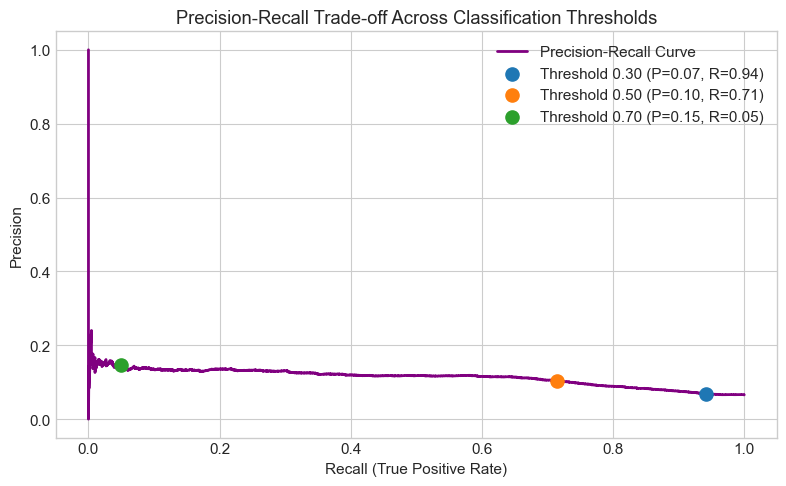

In [22]:
thresholds = [0.30, 0.50, 0.70]
threshold_results = []

for t in thresholds:
    t_pred = (final_prob >= t).astype(int)
    p = precision_score(y_test, t_pred, zero_division=0)
    r = recall_score(y_test, t_pred, zero_division=0)
    f = f1_score(y_test, t_pred, zero_division=0)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, t_pred).ravel()
    threshold_results.append({
        "Threshold": f"{t:.2f}",
        "Precision": p,
        "Recall": r,
        "F1": f,
        "Caught (TP)": tp_t,
        "Missed (FN)": fn_t,
        "False Alarms (FP)": fp_t
    })

threshold_df = pd.DataFrame(threshold_results)
print("=== Challenge Exercise: Threshold Sensitivity Table ===")
display(threshold_df.style.format({
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "Caught (TP)": "{:,}",
    "Missed (FN)": "{:,}",
    "False Alarms (FP)": "{:,}"
}))

# Plot Precision-Recall Curve with marked thresholds
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, final_prob)

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, color="purple", lw=2, label="Precision-Recall Curve")
for t in thresholds:
    t_pred = (final_prob >= t).astype(int)
    p = precision_score(y_test, t_pred, zero_division=0)
    r = recall_score(y_test, t_pred, zero_division=0)
    plt.scatter([r], [p], s=90, zorder=5, label=f"Threshold {t:.2f} (P={p:.2f}, R={r:.2f})")

plt.xlabel("Recall (True Positive Rate)")
plt.ylabel("Precision")
plt.title("Precision-Recall Trade-off Across Classification Thresholds")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Which threshold would you choose if missing a genuinely late order were very expensive?
> **Answer:** **Choose Threshold = 0.30.**
> 
> **Reasoning:**
> * At $\text{threshold} = 0.30$, the model captures **1,231 out of 1,307 late deliveries**—achieving an extraordinary **94.19% Recall**! Only 76 late orders are missed.
> * If missing a delivery carries severe penalties (e.g. lost lifetime customer value, SLA fines, negative marketplace ratings), operating at threshold 0.30 guarantees that almost every delay is intercepted and mitigated proactively.

## 30. Reflection

### Complete the following:

* **Before Lab 7:**
  > *"I thought a good ML model was one that simply achieved 90%+ Accuracy on the dataset."*
* **After Lab 7:**
  > *"I now understand that evaluating a model means inspecting the confusion matrix, auditing class-specific errors (precision vs recall), measuring threshold-independent ranking (ROC-AUC), and validating across multiple folds to verify stability."*
* **Most Important Metric:**
  > *"For late delivery prediction, **Recall** and **ROC-AUC** are paramount because false negatives carry substantially greater business cost than false alarms."*
* **Cross-Validation Lesson:**
  > *"A single test score can be lucky or unlucky; cross-validation mean and standard deviation are necessary to establish statistical confidence and prove repeatability."*
* **Deployment Decision:**
  > *"Based on my results, I **would consider this model ready for operational deployment** as an early-warning routing filter to prioritize at-risk orders in warehouses, while avoiding punitive automated penalties that require high precision."*

---

## 31. Key Takeaways

1. **Accuracy is only one view:** A model can boast 93% accuracy while completely failing to identify critical minority-class risks.
2. **Confusion matrix tells the story of errors:** True positives, true negatives, false positives, and false negatives explain the real business consequences.
3. **Precision and recall answer different questions:** Precision asks *"How many alarms were real?"*; Recall asks *"How many problems did we catch?"*.
4. **F1 balances precision and recall:** The harmonic mean penalizes models that sacrifice one metric completely.
5. **ROC-AUC evaluates ranking ability:** Evaluates discrimination across all classification thresholds independent of decision boundaries.
6. **Cross-validation improves confidence:** Evaluating across multiple folds prevents reliance on a single fortuitous split.
7. **The test set should remain unseen:** Holdout data must be touched only once at the conclusion of model development.
8. **Pipelines help prevent leakage:** Embedding preprocessing inside scikit-learn pipelines ensures validation fold statistics never leak into training.

---

## 32. Final Mental Model & Course Progression

```text
                               DATA
                                 |
                                 v
                       [ Train / Test Split ]
                                 |
         +-----------------------+-----------------------+
         |                                               |
         v                                               v
+------------------+                            +------------------+
|  Training Data   |                            |    Test Data     |
+------------------+                            |   Still Unseen   |
         |                                      +------------------+
         v                                               |
  Cross-Validation                                       |
         |                                               |
         v                                               |
 Model Development                                       |
         |                                               |
         v                                               |
Select Final Model                                       |
         |                                               |
         +---------------------> [ Final Evaluation ] <--+
                                         |
                                         v
                             "Can we trust this result?"
```

### The Progression Across Our Labs
* **Lab 1:** Understand the Data
* **Lab 2:** Build the Analytical Base Table (ABT)
* **Lab 3:** Understand & Clean the Data (Quality & EDA)
* **Lab 4:** Build a Reproducible ML Pipeline
* **Lab 5:** Foundations of Optimization (OLS & Gradient Descent)
* **Lab 6:** Engineer & Select Features (*"Can we create better signals?"*)
* **Lab 7:** Evaluate the Model & Cross-Validation (*"Can we trust the model's performance?"*)

---

> ### Instructor Note
> *"Good according to which metric, for which business problem, and compared with what baseline?"*  
> The confusion matrix is the anchor concept. A single performance number is not the same thing as reliable evidence of model quality.
